## Cell 1 — Install Dependencies

In [3]:
# Install required packages
!pip install ultralytics roboflow onnx onnxruntime opencv-python-headless matplotlib -q

# Verify GPU
import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU detected — switch runtime to T4 GPU for faster training")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 89.1 MB/s eta 0:00:00
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4


## Cell 2 — Download Safety Helmet Dataset (Roboflow)






In [4]:
from roboflow import Roboflow
import os

#ROBOFLOW API KEY BELOW
ROBOFLOW_API_KEY = "00sNpfIYGYuKCpkTN8b4"

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# This single dataset has 2500+ images already merged and cleaned
project = rf.workspace("roboflow-universe-projects").project("construction-site-safety")
dataset = project.version(28).download("yolov8")

DATASET_PATH = dataset.location
print(f"Train images : {len(os.listdir(DATASET_PATH+'/train/images'))}")
print(f"Valid images : {len(os.listdir(DATASET_PATH+'/valid/images'))}")
print(f"Test  images : {len(os.listdir(DATASET_PATH+'/test/images'))}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Construction-Site-Safety-28 in yolov8:: 100%|██████████| 5614/5614 [00:00<00:00, 6659.88it/s]

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Train images : 2605
Valid images : 114
Test  images : 82


In [5]:
import yaml
with open(f"{DATASET_PATH}/data.yaml") as f:
    cfg = yaml.safe_load(f)
print("Classes:", cfg['names'])
print("Num classes:", cfg['nc'])

Classes: ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']
Num classes: 10


## 🔍 Cell 3 — Explore Dataset (Sanity Check)

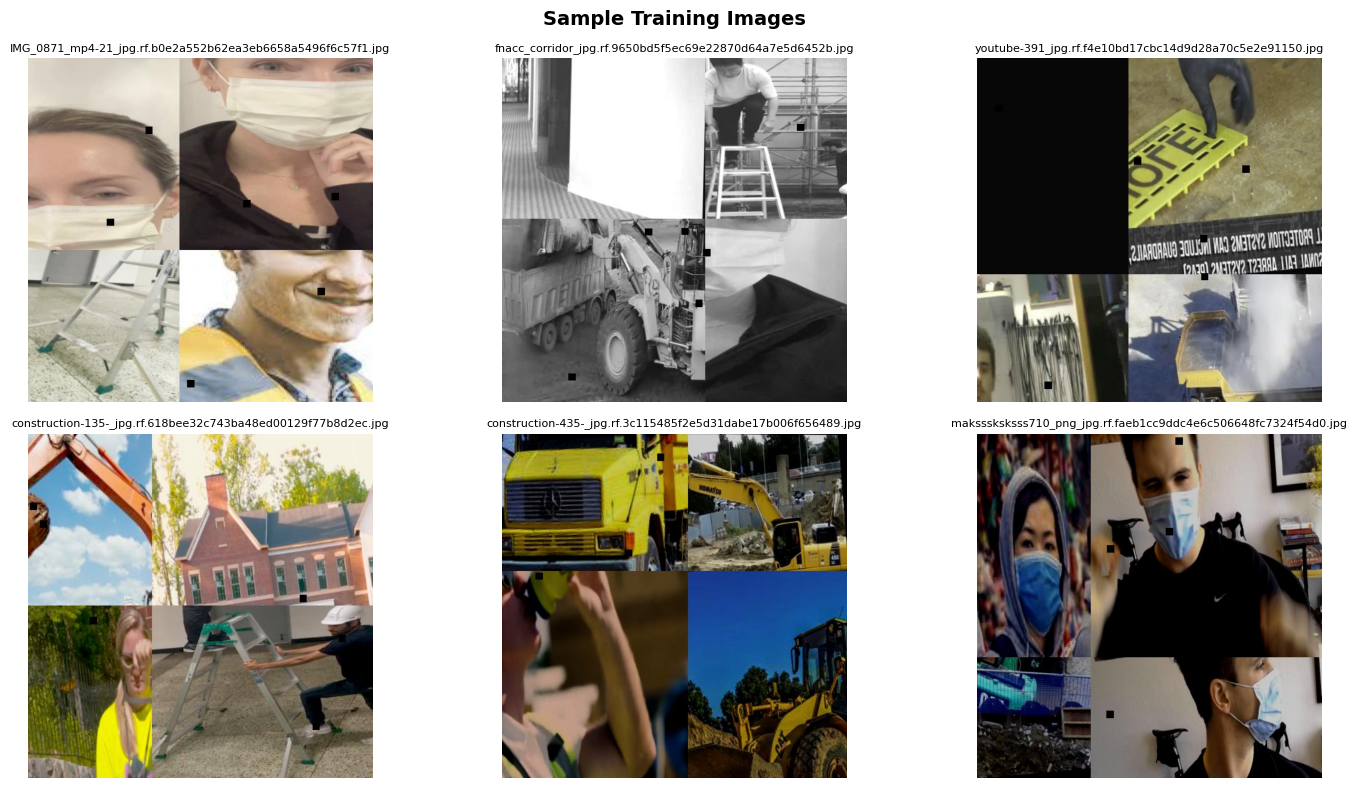


Dataset classes: ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']
Number of classes: 10


In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob, random

# Show 6 random training images
images = glob.glob(f"{DATASET_PATH}/train/images/*.jpg")
sample = random.sample(images, min(6, len(images)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, img_path in zip(axes.flatten(), sample):
    ax.imshow(mpimg.imread(img_path))
    ax.set_title(img_path.split('/')[-1], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print class distribution
import yaml
with open(f"{DATASET_PATH}/data.yaml") as f:
    data_cfg = yaml.safe_load(f)
print("\nDataset classes:", data_cfg.get('names', []))
print("Number of classes:", data_cfg.get('nc', 0))

##Cell 4 — Train YOLOv8s for PPE Detection


In [8]:
from ultralytics import YOLO

# Start from pretrained since previous session was reset
ppe_model = YOLO('yolov8s.pt')

results = ppe_model.train(
    data     = f"{DATASET_PATH}/data.yaml",
    epochs   = 50,
    imgsz    = 640,
    batch    = 16,
    device   = 0,
    project  = 'visionguard',
    name     = 'ppe_detector_v2',
    patience = 10,
    save     = True,
    hsv_h      = 0.015,
    hsv_s      = 0.7,
    hsv_v      = 0.4,
    fliplr     = 0.5,
    mosaic     = 1.0,
    mixup      = 0.1,
    degrees    = 10.0,
    scale      = 0.5,
    copy_paste = 0.1,
)

print("\n✅ Training complete!")
for idx, name in ppe_model.names.items():
    print(f"  {idx} : {name}")

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Construction-Site-Safety-28/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_detector_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

In [9]:
# Save to Google Drive immediately after training
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy(
    '/content/runs/detect/visionguard/ppe_detector_v2/weights/best.pt',
    '/content/drive/MyDrive/visionguard_best.pt'
)
print("✅ Saved to Google Drive!")

Mounted at /content/drive
✅ Saved to Google Drive!


##Cell 5 — Evaluate PPE Model

In [10]:
import os

# Find where best.pt was actually saved
for root, dirs, files in os.walk('/content'):
    for file in files:
        if file == 'best.pt':
            print(os.path.join(root, file))

/content/runs/detect/visionguard/ppe_detector_v2/weights/best.pt


Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1913.1±675.5 MB/s, size: 59.8 KB)
val: Scanning /content/Construction-Site-Safety-28/test/labels.cache... 82 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 26.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.6it/s 3.7s
                   all         82        760      0.917      0.701      0.782      0.425
               Hardhat         30        110          1      0.825      0.947      0.558
                  Mask         16         28      0.948       0.75      0.762      0.438
            NO-Hardhat         25         41       0.81      0.537      0.592      0.317
               NO-Mask         30         79      0.929      0.664      0.789      0.335
        NO-Safety Vest         36

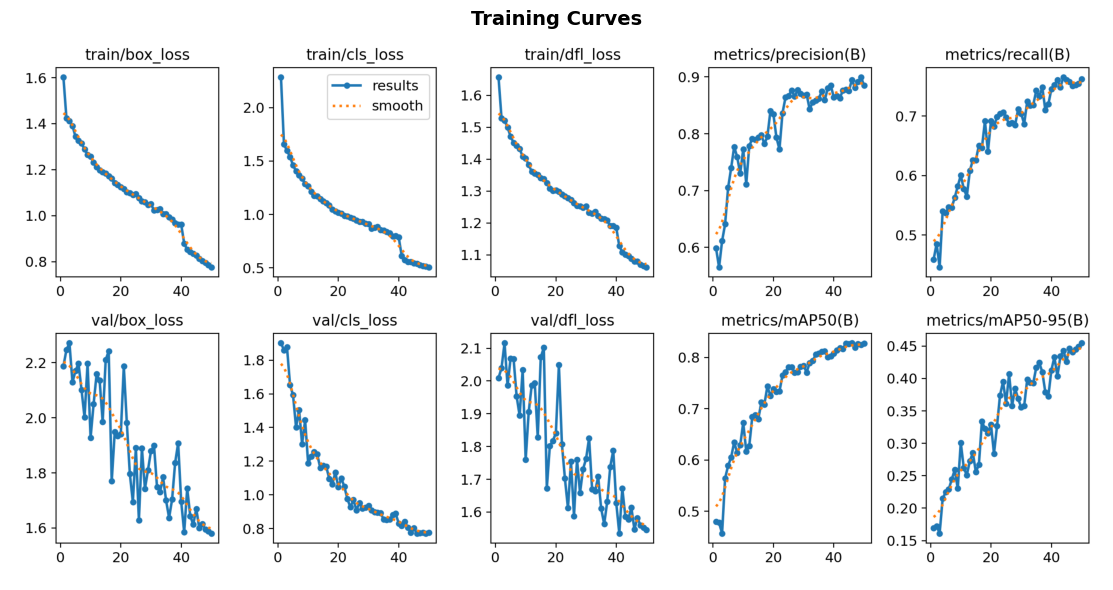

In [14]:
from ultralytics import YOLO

# Load best weights
best_ppe = YOLO('/content/runs/detect/visionguard/ppe_detector_v2/weights/best.pt')


# Validate on test set
metrics = best_ppe.val(data=f"{DATASET_PATH}/data.yaml", split='test')

print("\n📊 PPE Model Evaluation Results")
print("="*40)
print(f"mAP50      : {metrics.box.map50:.4f}")
print(f"mAP50-95   : {metrics.box.map:.4f}")
print(f"Precision  : {metrics.box.mp:.4f}")
print(f"Recall     : {metrics.box.mr:.4f}")

import matplotlib.pyplot as plt
import matplotlib.image as mpimg


results_img = '/content/runs/detect/visionguard/ppe_detector_v2/results.png'

fig, ax = plt.subplots(figsize=(15, 6))
ax.imshow(mpimg.imread(results_img))
ax.axis('off')
ax.set_title('Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


##Cell 6 — Setup YOLOv8-Pose (Fall Detection)



In [15]:
from ultralytics import YOLO
import numpy as np

# Load pretrained pose model
pose_model = YOLO('yolov8s-pose.pt')

print("✅ Pose model loaded!")
print(f"Model task   : {pose_model.task}")
print(f"Keypoints    : 17 (COCO format)")
print()

# COCO keypoint reference
KEYPOINTS = {
    0: 'nose',        1: 'left_eye',    2: 'right_eye',
    3: 'left_ear',    4: 'right_ear',   5: 'left_shoulder',
    6: 'right_shoulder', 7: 'left_elbow', 8: 'right_elbow',
    9: 'left_wrist',  10: 'right_wrist', 11: 'left_hip',
    12: 'right_hip',  13: 'left_knee',  14: 'right_knee',
    15: 'left_ankle', 16: 'right_ankle'
}
print("Keypoint indices:")
for k, v in KEYPOINTS.items():
    print(f"  [{k:2d}] {v}")

# Fall detection function (will be used in inference engine)
def is_fall_detected(keypoints, bbox):
    """
    keypoints : numpy array of shape (17, 3) → [x, y, confidence]
    bbox      : [x1, y1, x2, y2]
    Returns   : (bool, str) → (fall_detected, reason)
    """
    x1, y1, x2, y2 = bbox
    w = x2 - x1
    h = y2 - y1

    # Check 1: bounding box aspect ratio
    aspect_ratio = w / (h + 1e-6)
    is_horizontal = aspect_ratio > 1.2

    # Check 2: hip-to-shoulder angle
    # Indices: left_shoulder=5, right_shoulder=6, left_hip=11, right_hip=12
    shoulder_conf = min(keypoints[5][2], keypoints[6][2])
    hip_conf      = min(keypoints[11][2], keypoints[12][2])

    if shoulder_conf > 0.3 and hip_conf > 0.3:
        shoulder_mid = np.array([
            (keypoints[5][0] + keypoints[6][0]) / 2,
            (keypoints[5][1] + keypoints[6][1]) / 2
        ])
        hip_mid = np.array([
            (keypoints[11][0] + keypoints[12][0]) / 2,
            (keypoints[11][1] + keypoints[12][1]) / 2
        ])
        torso_vec    = shoulder_mid - hip_mid
        vertical_vec = np.array([0, -1])
        cos_angle    = np.dot(torso_vec, vertical_vec) / (
            np.linalg.norm(torso_vec) * np.linalg.norm(vertical_vec) + 1e-6
        )
        angle_deg = np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))
        is_tilted = angle_deg > 45
    else:
        is_tilted = False

    fall = is_horizontal and is_tilted
    reason = f"aspect={aspect_ratio:.2f}, angle={angle_deg:.1f}°" if fall else ""
    return fall, reason

print("\n✅ Fall detection function defined!")

✅ Pose model loaded!
Model task   : pose
Keypoints    : 17 (COCO format)

Keypoint indices:
  [ 0] nose
  [ 1] left_eye
  [ 2] right_eye
  [ 3] left_ear
  [ 4] right_ear
  [ 5] left_shoulder
  [ 6] right_shoulder
  [ 7] left_elbow
  [ 8] right_elbow
  [ 9] left_wrist
  [10] right_wrist
  [11] left_hip
  [12] right_hip
  [13] left_knee
  [14] right_knee
  [15] left_ankle
  [16] right_ankle

✅ Fall detection function defined!


##Cell 7 — Test Both Models on Sample Images

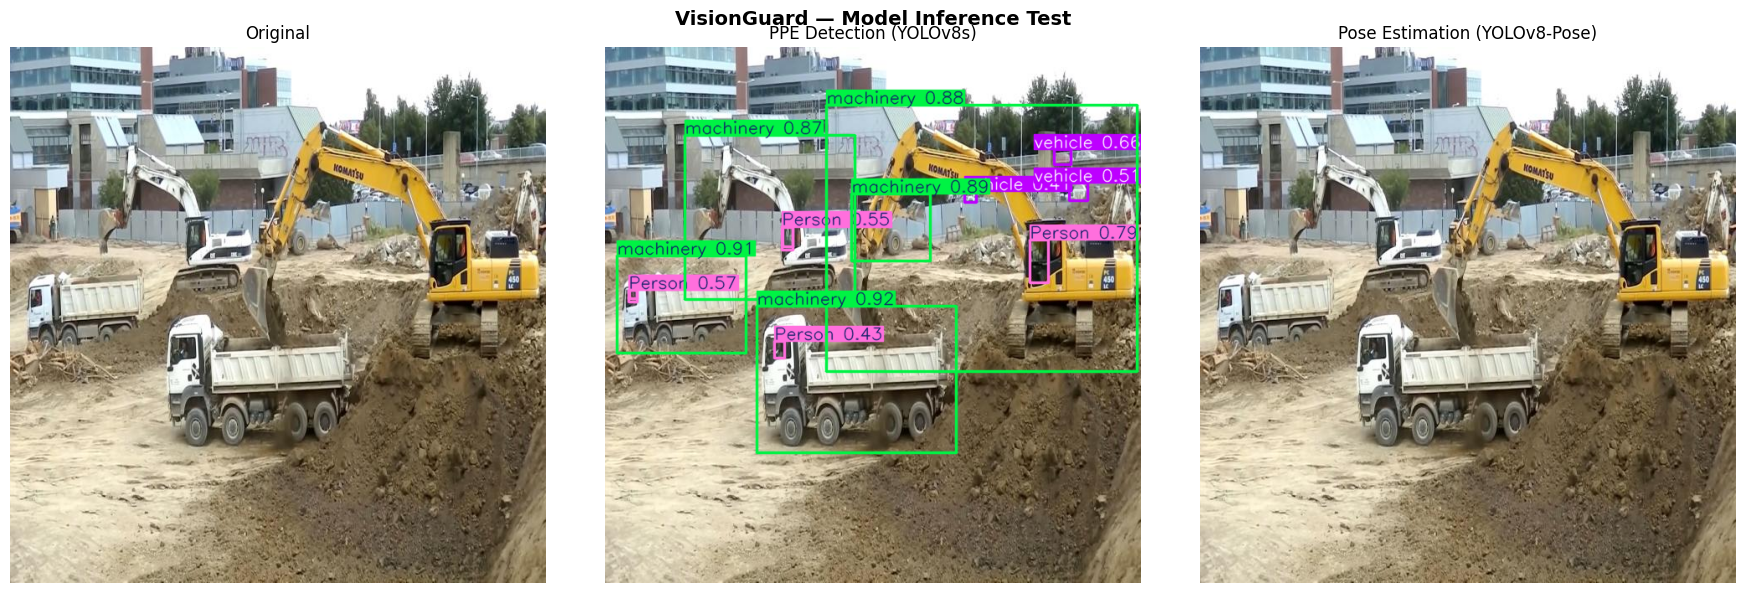


PPE Detections:
  machinery            conf=0.92
  machinery            conf=0.91
  machinery            conf=0.89
  machinery            conf=0.88
  machinery            conf=0.87
  Person               conf=0.79
  vehicle              conf=0.66
  Person               conf=0.57
  Person               conf=0.55
  vehicle              conf=0.51
  Person               conf=0.47
  Person               conf=0.43
  Person               conf=0.42
  vehicle              conf=0.41

Pose Detections:
  Persons detected: 0


In [16]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import glob, random
from ultralytics import YOLO

# Load best weights with correct path
best_ppe = YOLO('/content/runs/detect/visionguard/ppe_detector_v2/weights/best.pt')

# Pick a test image
test_images = glob.glob(f"{DATASET_PATH}/test/images/*.jpg")
test_img_path = random.choice(test_images)
img = cv2.imread(test_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Run both models
ppe_result  = best_ppe(img, conf=0.4, verbose=False)[0]
pose_result = pose_model(img, conf=0.4, verbose=False)[0]

# Draw detections
ppe_annotated  = ppe_result.plot()
pose_annotated = pose_result.plot()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_rgb)
axes[0].set_title('Original', fontsize=12)
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(ppe_annotated, cv2.COLOR_BGR2RGB))
axes[1].set_title('PPE Detection (YOLOv8s)', fontsize=12)
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(pose_annotated, cv2.COLOR_BGR2RGB))
axes[2].set_title('Pose Estimation (YOLOv8-Pose)', fontsize=12)
axes[2].axis('off')

plt.suptitle('VisionGuard — Model Inference Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print detections
print("\nPPE Detections:")
for box in ppe_result.boxes:
    cls  = int(box.cls[0])
    conf = float(box.conf[0])
    name = ppe_result.names[cls]
    print(f"  {name:20s} conf={conf:.2f}")

print("\nPose Detections:")
print(f"  Persons detected: {len(pose_result.boxes)}")
if len(pose_result.boxes) > 0:
    print(f"  Keypoints shape : {pose_result.keypoints.xy.shape}")

## Cell 8 — Export Both Models to ONNX


In [17]:
import os
os.makedirs('visionguard/exported_models', exist_ok=True)

best_ppe = YOLO('/content/runs/detect/visionguard/ppe_detector_v2/weights/best.pt')

# Export PPE model
print("Exporting PPE model to ONNX...")
best_ppe = YOLO('/content/runs/detect/visionguard/ppe_detector_v2/weights/best.pt')
best_ppe.export(format='onnx', imgsz=640, simplify=True, opset=12, dynamic=False)
!cp /content/runs/detect/visionguard/ppe_detector_v2/weights/best.onnx visionguard/exported_models/ppe_detector.onnx
print("✅ PPE model exported")

# Export Pose model
print("\nExporting Pose model to ONNX...")
pose_model.export(format='onnx', imgsz=640, simplify=True, opset=12, dynamic=False)
!cp /content/yolov8s-pose.onnx visionguard/exported_models/pose_detector.onnx
print("✅ Pose model exported")

# Print sizes
for fname in ['ppe_detector.onnx', 'pose_detector.onnx']:
    fpath = f'visionguard/exported_models/{fname}'
    size_mb = os.path.getsize(fpath) / (1024*1024)
    print(f"  {fname:25s} → {size_mb:.1f} MB")

Exporting PPE model to ONNX...
Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs

PyTorch: starting from '/content/runs/detect/visionguard/ppe_detector_v2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 14, 8400) (21.5 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 300ms
Prepared 3 packages in 4.95s
Installed 3 packages in 70ms
 + colorama==0.4.6
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 5.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 1

In [18]:
import shutil, os

#full paths
shutil.copy(
    '/content/runs/detect/visionguard/ppe_detector_v2/weights/best.onnx',
    '/content/visionguard/exported_models/ppe_detector.onnx'
)
shutil.copy(
    '/content/yolov8s-pose.onnx',
    '/content/visionguard/exported_models/pose_detector.onnx'
)

print("✅ Models copied to exported_models folder")
for fname in ['ppe_detector.onnx', 'pose_detector.onnx']:
    fpath = f'/content/visionguard/exported_models/{fname}'
    size_mb = os.path.getsize(fpath) / (1024*1024)
    print(f"  {fname:25s} → {size_mb:.1f} MB")

✅ Models copied to exported_models folder
  ppe_detector.onnx         → 42.7 MB
  pose_detector.onnx        → 44.6 MB


##Cell 9 — Validate ONNX Models


In [19]:
import onnxruntime as ort
import numpy as np

def validate_onnx_model(model_path, model_name):
    print(f"\nValidating {model_name}...")
    session = ort.InferenceSession(model_path, providers=['CPUExecutionProvider'])

    # Model info
    inp = session.get_inputs()[0]
    out = session.get_outputs()
    print(f"  Input  : {inp.name} → shape {inp.shape} dtype {inp.type}")
    for o in out:
        print(f"  Output : {o.name} → shape {o.shape}")

    # Dummy inference
    dummy = np.random.randn(1, 3, 640, 640).astype(np.float32)
    preds = session.run(None, {inp.name: dummy})
    print(f"  Inference OK — output shape: {preds[0].shape}")
    return True

# Fixed: full paths
validate_onnx_model('/content/visionguard/exported_models/ppe_detector.onnx',  'PPE Detector')
validate_onnx_model('/content/visionguard/exported_models/pose_detector.onnx', 'Pose Detector')

print("\n✅ Both ONNX models validated successfully!")


Validating PPE Detector...
  Input  : images → shape [1, 3, 640, 640] dtype tensor(float)
  Output : output0 → shape [1, 14, 8400]
  Inference OK — output shape: (1, 14, 8400)

Validating Pose Detector...
  Input  : images → shape [1, 3, 640, 640] dtype tensor(float)
  Output : output0 → shape [1, 56, 8400]
  Inference OK — output shape: (1, 56, 8400)

✅ Both ONNX models validated successfully!


##Cell 10 — Package & Download Everything


In [20]:
import shutil, os, json, yaml
from google.colab import files

os.makedirs('/content/visionguard/exported_models', exist_ok=True)

# Save fall detection utility
fall_code = '''
import numpy as np

LEFT_SHOULDER, RIGHT_SHOULDER = 5, 6
LEFT_HIP,      RIGHT_HIP      = 11, 12

def is_fall_detected(keypoints, bbox, aspect_thresh=1.2, angle_thresh=45):
    x1, y1, x2, y2 = bbox
    w = x2 - x1
    h = y2 - y1
    aspect_ratio = w / (h + 1e-6)
    s_conf = min(keypoints[LEFT_SHOULDER][2], keypoints[RIGHT_SHOULDER][2])
    h_conf = min(keypoints[LEFT_HIP][2],      keypoints[RIGHT_HIP][2])
    angle_deg = 0.0
    if s_conf > 0.3 and h_conf > 0.3:
        s_mid = [(keypoints[LEFT_SHOULDER][0]+keypoints[RIGHT_SHOULDER][0])/2,
                 (keypoints[LEFT_SHOULDER][1]+keypoints[RIGHT_SHOULDER][1])/2]
        h_mid = [(keypoints[LEFT_HIP][0]+keypoints[RIGHT_HIP][0])/2,
                 (keypoints[LEFT_HIP][1]+keypoints[RIGHT_HIP][1])/2]
        vec   = np.array(s_mid) - np.array(h_mid)
        cos_a = np.dot(vec, [0,-1]) / (np.linalg.norm(vec) + 1e-6)
        angle_deg = float(np.degrees(np.arccos(np.clip(cos_a, -1, 1))))
    fall = (aspect_ratio > aspect_thresh) and (angle_deg > angle_thresh)
    return fall, aspect_ratio, angle_deg
'''
with open('/content/visionguard/exported_models/fall_detection.py', 'w') as f:
    f.write(fall_code)

# Save class map
class_map = {
    "names"         : list(best_ppe.names.values()),
    "alert_classes" : ["NO-Hardhat", "NO-Safety Vest", "NO-Mask"],
    "info_classes"  : ["Hardhat", "Safety Vest", "Mask", "Person",
                       "Safety Cone", "machinery", "vehicle"],
    "nc"            : 10
}
with open('/content/visionguard/exported_models/class_map.json', 'w') as f:
    json.dump(class_map, f, indent=2)

# Save model metadata
meta = {
    'ppe_model'    : {'file': 'ppe_detector.onnx',  'input_size': 640, 'task': 'detect'},
    'pose_model'   : {'file': 'pose_detector.onnx', 'input_size': 640, 'task': 'pose'},
    'classes'      : list(best_ppe.names.values()),
    'alert_classes': ["NO-Hardhat", "NO-Safety Vest", "NO-Mask"],
    'hazard_rules' : {
        'fall_aspect_thresh' : 1.2,
        'fall_angle_thresh'  : 45,
        'alert_frame_window' : 5
    }
}
with open('/content/visionguard/exported_models/model_meta.yaml', 'w') as f:
    yaml.dump(meta, f)

# Zip and download
shutil.make_archive('/content/visionguard_models', 'zip', '/content/visionguard/exported_models')

print("✅ Package ready!")
print(f"   Size: {os.path.getsize('/content/visionguard_models.zip')/(1024*1024):.1f} MB")
print("\nContents:")
for f in os.listdir('/content/visionguard/exported_models'):
    sz = os.path.getsize(f'/content/visionguard/exported_models/{f}') / (1024*1024)
    print(f"  {f:35s} {sz:.2f} MB")

print("\n⬇️  Downloading visionguard_models.zip...")
files.download('/content/visionguard_models.zip')

✅ Package ready!
   Size: 73.5 MB

Contents:
  class_map.json                      0.00 MB
  ppe_detector.onnx                   42.69 MB
  model_meta.yaml                     0.00 MB
  pose_detector.onnx                  44.65 MB
  fall_detection.py                   0.00 MB

⬇️  Downloading visionguard_models.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>